In [285]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, get_wmse

In [286]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [287]:
with open("simu2b_data/simu2b_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
df_study = df_study.query("session < 20")  # for testing
df_test = df_test.query("session < 20")

In [288]:
df_study

,session,subj,list,trial,word1,word2,itemno1,itemno2
0,0,101,0,-1,formal,positive,422,759
1,0,101,0,0,skin,careful,930,158
2,0,101,0,1,upon,miss,1086,643
3,0,101,0,2,single,tradition,923,1059
4,0,101,0,3,prove,airport,793,35
...,...,...,...,...,...,...,...,...
9595,19,120,7,54,winter,cause,1135,166
9596,19,120,7,55,master,sent,612,885
9597,19,120,7,56,drop,homes,306,495
9598,19,120,7,57,south,correct,952,234


In [289]:
df_test

,session,subj,list,trial,word1,word2,itemno1,itemno2,type,lag,forward
0,0,101,0,-1,waste,degree,1112,269,rearranged,2,0
1,0,101,0,0,needed,able,673,2,rearranged,1,1
2,0,101,0,1,single,clean,923,193,rearranged,3,1
3,0,101,0,2,train,useful,1061,1089,rearranged,2,1
4,0,101,0,3,knees,various,552,1095,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...
9595,19,120,7,54,square,clean,965,193,rearranged,2,1
9596,19,120,7,55,relations,extra,830,366,intact,-1,0
9597,19,120,7,56,captain,baby,154,82,intact,-1,0
9598,19,120,7,57,leave,near,568,670,intact,-1,0


In [290]:
sem_mat = np.load("simu2b_data/simu2b_smat.npy")

## Run CMR-IA

In [291]:
# read pso results
_, _, what_to_fit = make_boundary(sim_name="2b")
optim_params = np.loadtxt("simu2b_data/2b_250519_200-100.txt")

# get params
params = cmr.make_default_params()
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params.update(use_new_context=True, use_flexible_thresh=True)
# beta_enc 0.4 can decrease, gamma_fc 0.4 can decrease
params.update(beta_rec_post=0, beta_distract=0, s_fc=0)
params.update(beta_enc=0.4)
params

{'beta_enc': 0.4,
 'beta_rec': 0.5,
 'beta_cue': 0.50953,
 'beta_rec_post': 0,
 'beta_distract': 0,
 'beta_enc_inpair': -1,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 1.037511,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': True,
 'thresh_rate': 6.815025,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.084753,
 'gamma_cf': 0.5}

In [315]:
out_dir = "/home1/beigejin/CMR-IA/Modeling/fitting/past_fits/2b_250519_200-100/outfiles"

iter = 45
min_err = np.inf
for p in range(200):
    path = f"{out_dir}/{iter}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"]
        if err < min_err:
            min_err = err
            best_p = p
            best_b = b
    except:
        err = np.nan
        b = np.nan

best_p, best_b, min_err

# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, use_flexible_thresh=True)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="2b")
# optim_params = np.loadtxt("simu8_data/8_250309_200-200.txt")
optim_params = best_b
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params.update(beta_enc=0.12, gamma_fc=0.08)
params

{'beta_enc': 0.12,
 'beta_rec': 0.5,
 'beta_cue': 0.6311530526683066,
 'beta_rec_post': 0.6030549756842857,
 'beta_distract': 0.3695955289769658,
 'beta_enc_inpair': -1,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0.002402866977623651,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 1.0516481577803958,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': True,
 'thresh_rate': 6.313694722184739,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.08,
 'gamma_cf': 0.5}

In [316]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.5,
#     beta_cue=0.5,
#     beta_distract=0.9,
#     beta_rec_post=0.9,
#     gamma_fc=0.5,
#     s_fc=0.1,
#     c_thresh_assoc=1,
#     use_new_context=True,
#     use_flexible_thresh=True,
# )
# params

In [317]:
# task = "Recog"
# mode = "Osth"

# sessions = np.unique(df_study.session)
# list_num = len(np.unique(df_study.list))
# df_thin = df_test[["session", "list", "itemno1", "itemno2"]]
# sess = 3

# # extarct the session data
# pres_mat = df_study.loc[df_study.session == sess, ["itemno1", "itemno2"]].to_numpy()
# pres_mat = np.reshape(pres_mat, (list_num, -1, 2))
# cue_mat = df_thin.loc[df_thin.session == sess, ["itemno1", "itemno2"]].to_numpy()
# cue_mat = np.reshape(cue_mat, (list_num, -1, 2))

# # run CMR for each session
# cmr_m = cmr.CMR(params, pres_mat, sem_mat, source_mat=None, rec_mat=None, ffr_mat=None, cue_mat=cue_mat, task=task, mode=mode)

# cmr_m.run_norm_recog_single_sess()

In [318]:
# run the model
df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat, mode="Osth")
df_simu

100%|██████████| 20/20 [01:35<00:00,  4.78s/it]

CMR Time: 95.58812546730042


,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob
0,0,0,1112,269,0,0,0.061899,0.094800,0.491775
1,0,0,673,2,0,0,0.057695,0.065150,0.498136
2,0,0,923,193,0,0,0.036208,0.060683,0.493882
3,0,0,1061,1089,1,0,0.045616,0.038119,0.501874
4,0,0,552,1095,0,0,0.042123,0.047955,0.498542
...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.039613,0.043123,0.499122
9596,19,7,830,366,1,0,0.044122,0.041662,0.500615
9597,19,7,154,82,1,0,0.046630,0.046392,0.500060
9598,19,7,568,670,0,0,0.045940,0.049034,0.499226


In [319]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward
0,0,0,1112,269,0,0,0.061899,0.094800,0.491775,101,-1,waste,degree,rearranged,2,0
1,0,0,673,2,0,0,0.057695,0.065150,0.498136,101,0,needed,able,rearranged,1,1
2,0,0,923,193,0,0,0.036208,0.060683,0.493882,101,1,single,clean,rearranged,3,1
3,0,0,1061,1089,1,0,0.045616,0.038119,0.501874,101,2,train,useful,rearranged,2,1
4,0,0,552,1095,0,0,0.042123,0.047955,0.498542,101,3,knees,various,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.039613,0.043123,0.499122,120,54,square,clean,rearranged,2,1
9596,19,7,830,366,1,0,0.044122,0.041662,0.500615,120,55,relations,extra,intact,-1,0
9597,19,7,154,82,1,0,0.046630,0.046392,0.500060,120,56,captain,baby,intact,-1,0
9598,19,7,568,670,0,0,0.045940,0.049034,0.499226,120,57,leave,near,intact,-1,0


In [320]:
df_simu.groupby("lag").trial.mean()

lag
-1    28.531042
 1    29.098958
 2    28.522917
 3    28.580208
 4    28.192708
 5    27.950000
Name: trial, dtype: float64

In [321]:
df_simu = df_simu.query("trial > 20").copy() ##!

In [322]:
# calculate loss
# s_resp = df_simu["s_resp"].to_numpy()
# yes = df_simu["yes"].to_numpy()
# err = np.nansum(np.abs(s_resp - yes))
# err

In [323]:
# if SAVERES:
#     df_simu.to_pickle("simu2b_data/simu2b_result.pkl")

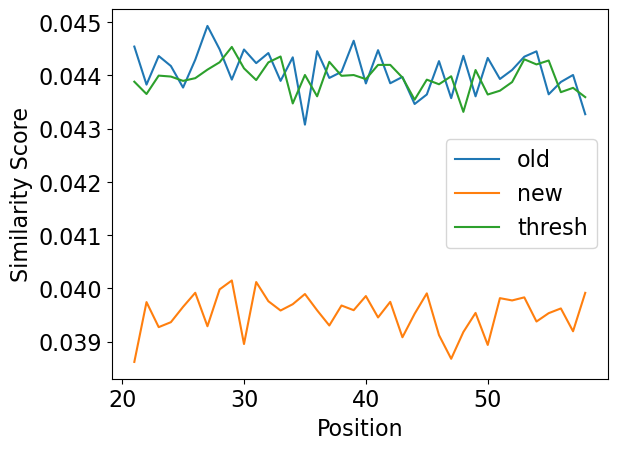

In [324]:
old_csim_pos = df_simu.query("type == 'intact'").groupby("trial").csim.mean()
old_pos = np.unique(df_simu.query("type == 'intact'").trial.to_numpy())
new_csim_pos = df_simu.query("type == 'rearranged'").groupby("trial").csim.mean()
new_pos = np.unique(df_simu.query("type == 'rearranged'").trial.to_numpy())
cthresh_pos = df_simu.groupby("trial").thresh.mean()
pos = np.unique(df_simu.trial.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
# plt.ylim(0.8, 0.9)
plt.show()

## Analysis

In [325]:
df_simu["old"] = df_simu.apply(lambda x: 1 if x["type"] == "intact" else 0, axis=1)
df_simu["correct"] = df_simu["s_resp"] == df_simu["old"]
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward,old,correct
22,0,0,159,247,1,0,0.037596,0.034231,0.500841,101,21,carry,crowd,intact,-1,0,1,True
23,0,0,144,127,1,0,0.042760,0.039528,0.500808,101,22,busy,bound,intact,-1,0,1,True
24,0,0,706,611,0,0,0.040551,0.044959,0.498898,101,23,others,massive,rearranged,2,0,0,True
25,0,0,1025,230,0,0,0.037513,0.042649,0.498716,101,24,telephone,control,rearranged,1,1,0,True
26,0,0,751,71,0,0,0.033064,0.039456,0.498402,101,25,plus,attack,intact,-1,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.039613,0.043123,0.499122,120,54,square,clean,rearranged,2,1,0,True
9596,19,7,830,366,1,0,0.044122,0.041662,0.500615,120,55,relations,extra,intact,-1,0,1,True
9597,19,7,154,82,1,0,0.046630,0.046392,0.500060,120,56,captain,baby,intact,-1,0,1,True
9598,19,7,568,670,0,0,0.045940,0.049034,0.499226,120,57,leave,near,intact,-1,0,1,False


### Overall HR and FAR

In [326]:
# get yes rate
df_hrfar = df_simu.groupby(["session", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_hrfar = df_hrfar.pivot(index="session", columns="type", values="yes_rate").reset_index()
df_hrfar["hr"] = df_hrfar["intact"]
df_hrfar["far"] = 1 - df_hrfar["rearranged"]
df_hrfar

type,session,intact,rearranged,hr,far
0,0,0.527607,0.836879,0.527607,0.163121
1,1,0.500000,0.797297,0.500000,0.202703
2,2,0.493506,0.860000,0.493506,0.140000
3,3,0.515723,0.855172,0.515723,0.144828
4,4,0.503311,0.803922,0.503311,0.196078
5,5,0.496894,0.832168,0.496894,0.167832
6,6,0.493590,0.824324,0.493590,0.175676
7,7,0.506667,0.818182,0.506667,0.181818
8,8,0.560811,0.788462,0.560811,0.211538
9,9,0.580000,0.857143,0.580000,0.142857


In [327]:
df_hrfar_plot = pd.melt(df_hrfar, id_vars=["session"], value_vars=["hr", "far"], var_name="type", value_name="yes_rate")
df_hrfar_plot

,session,type,yes_rate
0,0,hr,0.527607
1,1,hr,0.500000
2,2,hr,0.493506
3,3,hr,0.515723
4,4,hr,0.503311
5,5,hr,0.496894
6,6,hr,0.493590
7,7,hr,0.506667
8,8,hr,0.560811
9,9,hr,0.580000


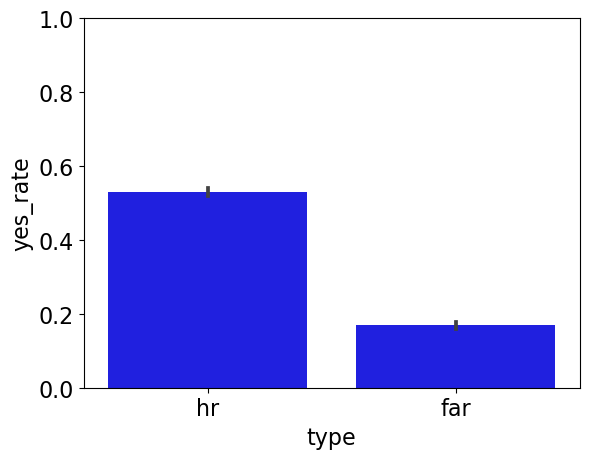

In [328]:
sns.barplot(data=df_hrfar_plot, x="type", y="yes_rate", color="blue")
plt.ylim(0, 1)
plt.show()

### Far with Lag

In [329]:
df_lure = df_simu.query("type == 'rearranged'").copy()
df_farlag = df_lure.groupby(["session", "lag"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_farlag["far"] = 1 - df_farlag["yes_rate"]
df_farlag

,session,lag,yes_rate,far
0,0,1,0.892857,0.107143
1,0,2,0.857143,0.142857
2,0,3,0.814815,0.185185
3,0,4,0.709677,0.290323
4,0,5,0.925926,0.074074
...,...,...,...,...
95,19,1,0.827586,0.172414
96,19,2,0.785714,0.214286
97,19,3,0.677419,0.322581
98,19,4,0.878788,0.121212


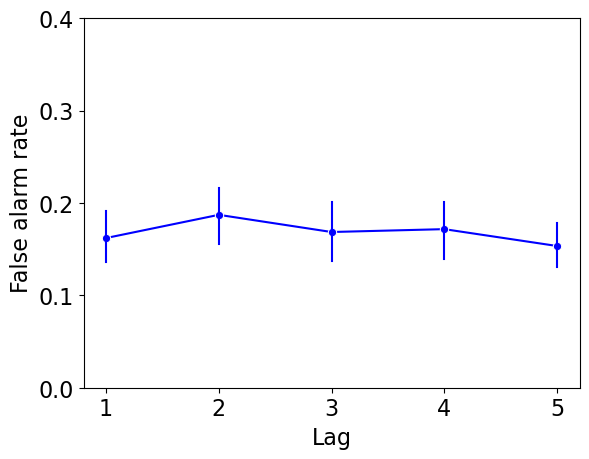

In [330]:
sns.lineplot(
    data=df_farlag,
    x="lag",
    y="far",
    color="blue",
    marker="o",
    err_style="bars",
)
plt.ylim(0, 0.4)
plt.xlim(0.8, 5.2)
plt.xticks(np.arange(1, 6))
plt.yticks(np.arange(0, 0.41, 0.1))
plt.xlabel("Lag")
plt.ylabel("False alarm rate")
plt.show()

In [331]:
df_farlag_csim = df_lure.query("forward == 1").groupby(["session", "lag"]).csim.mean().to_frame(name="csim").reset_index()
df_farlag_csim

,session,lag,csim
0,0,1,0.040602
1,0,2,0.040813
2,0,3,0.039111
3,0,4,0.041126
4,0,5,0.038595
...,...,...,...
95,19,1,0.040223
96,19,2,0.039128
97,19,3,0.040127
98,19,4,0.038616


In [332]:
sessions = df_farlag_csim.session.unique()
corrs = []
for sess in sessions:
    df_sess = df_farlag_csim.query("session == @sess")
    lag = df_sess["lag"].to_numpy()
    csim = df_sess["csim"].to_numpy()
    # do correlation
    corr = sp.stats.pearsonr(lag, csim)
    corrs.append(corr)
np.mean(corrs), np.std(corrs)

(0.15704039000085873, 0.493953223656776)

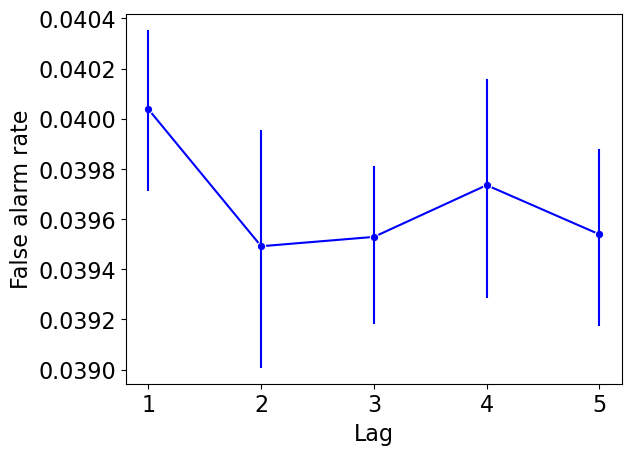

In [333]:
sns.lineplot(
    data=df_farlag_csim,
    x="lag",
    y="csim",
    color="blue",
    marker="o",
    err_style="bars",
)
# plt.ylim(0, 0.1)
plt.xlim(0.8, 5.2)
plt.xticks(np.arange(1, 6))
# plt.yticks(np.arange(0, 0.11, 0.01))
plt.xlabel("Lag")
plt.ylabel("False alarm rate")
plt.show()

### Error Check

In [334]:
# load ground truth
with open("simu2b_data/simu2b_gt.pkl", "rb") as f:
    hr_gt = pickle.load(f)
    hr_std_gt = pickle.load(f)
    far_gt = pickle.load(f)
    far_std_gt = pickle.load(f)
hr_gt, hr_std_gt, far_gt, far_std_gt

(0.5366186381796584,
 0.1633487638481977,
 array([0.21428165, 0.2174274 , 0.21721617, 0.21166567, 0.20021831]),
 array([0.14578635, 0.15351747, 0.16036269, 0.14002328, 0.13892722]))

In [335]:
hr = df_hrfar_plot.query("type == 'hr'").yes_rate.mean()
far = df_farlag.groupby("lag").far.mean().to_numpy()
hr, far

(0.5295531714346854,
 array([0.16200523, 0.18711729, 0.16851572, 0.17162403, 0.15339333]))

In [336]:
# calculate error
err = 5 * get_wmse(hr_gt, hr, hr_std_gt) + get_wmse(far_gt, far, far_std_gt)
err

0.4645207461685899